In [1]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
import torch.nn as nn

pretrained_weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=pretrained_weights)

### Thay classifier thành 10 class

In [2]:
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    10
)

In [3]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


In [4]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((300,300)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.05,0.05)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [6]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\train",
    transform=train_transform
)

val_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\val",
    transform=val_transform
)

test_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\test",
    transform=test_transform
)

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
     pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

### Optimizer

In [8]:
FREEZE_EPOCHS = 5
WEIGHT_DECAY = 1e-3

def set_feature_extractor_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable

def create_optimizer(model, fine_tune=False):
    if fine_tune:
        # Learning rate thấp cho backbone giúp tránh làm hỏng pretrained features.
        return torch.optim.AdamW(
            [
                {"params": model.features.parameters(), "lr": 1e-5},
                {"params": model.classifier.parameters(), "lr": 1e-4},
            ],
            weight_decay=WEIGHT_DECAY
        )

    return torch.optim.AdamW(
        model.classifier.parameters(),
        lr=3e-4,
        weight_decay=WEIGHT_DECAY
    )

# Giai đoạn warm-up: chỉ huấn luyện classifier.
set_feature_extractor_trainable(model, False)
optimizer = create_optimizer(model, fine_tune=False)

### Loss

In [9]:
import numpy as np

class_weights = np.load("../data/class_weights.npy")

weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights_tensor
)

In [10]:
print(class_weights)
print(len(class_weights))

[1.02265193 0.73679788 0.75999088 1.23766716 0.74007108 1.90606407
 0.61313949 0.89468314 2.66544    1.84689579]
10


### Scheduler

In [11]:
def create_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        threshold=1e-3,
        min_lr=1e-7,
    )

scheduler = create_scheduler(optimizer)

### Hàm Train

In [12]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    freeze_features=False
):

    model.train()
    # Giữ BatchNorm của backbone ở eval mode trong giai đoạn freeze.
    if freeze_features:
        model.features.eval()

    running_loss = 0

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        if torch.isnan(outputs).any():
            print(f"NaN output at batch {batch_idx}")
            return float("nan")

        loss = criterion(outputs, labels)

        if torch.isnan(loss):
            print(f"NaN loss at batch {batch_idx}")
            return float("nan")

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

### Evaluate

In [13]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Validation accuracy
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

### Train

In [14]:
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-3

best_val_loss = float("inf")
best_val_acc = 0.0
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    # Sau 5 epoch warm-up, unfreeze backbone và dùng learning rate nhỏ hơn.
    if epoch == FREEZE_EPOCHS:
        set_feature_extractor_trainable(model, True)
        optimizer = create_optimizer(model, fine_tune=True)
        scheduler = create_scheduler(optimizer)
        print("Unfreezing feature extractor for fine-tuning.")

    freeze_features = epoch < FREEZE_EPOCHS
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        freeze_features=freeze_features
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    if not np.isfinite(train_loss) or not np.isfinite(val_loss):
        print("Stopping because a non-finite loss was detected.")
        break

    scheduler.step(val_loss)
    learning_rates = [group["lr"] for group in optimizer.param_groups]
    stage = "classifier" if freeze_features else "fine-tune"
    print(
        f"Epoch {epoch+1:02d} [{stage}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {learning_rates}"
    )

    # Dùng validation loss cho checkpoint và early stopping.
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "../models/best_mobilenetv3.pth")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping! Best Val Loss: {best_val_loss:.4f}, "
            f"Val Acc at best loss: {best_val_acc:.4f}"
        )
        break

# Khôi phục trọng số tốt nhất thay vì giữ epoch cuối.
model.load_state_dict(torch.load("../models/best_mobilenetv3.pth", map_location=device))

Epoch 01 [classifier] | Train Loss: 1.2062 | Val Loss: 0.9489 | Val Acc: 0.6515 | LR: [0.0003]
Epoch 02 [classifier] | Train Loss: 0.8289 | Val Loss: 0.8721 | Val Acc: 0.6655 | LR: [0.0003]
Epoch 03 [classifier] | Train Loss: 0.7207 | Val Loss: 0.8047 | Val Acc: 0.6855 | LR: [0.0003]
Epoch 04 [classifier] | Train Loss: 0.6533 | Val Loss: 0.7646 | Val Acc: 0.7115 | LR: [0.0003]
Epoch 05 [classifier] | Train Loss: 0.6045 | Val Loss: 0.8037 | Val Acc: 0.6827 | LR: [0.0003]
Unfreezing feature extractor for fine-tuning.
Epoch 06 [fine-tune] | Train Loss: 1.0203 | Val Loss: 0.9178 | Val Acc: 0.6591 | LR: [1e-05, 0.0001]
Epoch 07 [fine-tune] | Train Loss: 0.7095 | Val Loss: 0.7594 | Val Acc: 0.7179 | LR: [1e-05, 0.0001]
Epoch 08 [fine-tune] | Train Loss: 0.5892 | Val Loss: 0.6562 | Val Acc: 0.7499 | LR: [1e-05, 0.0001]
Epoch 09 [fine-tune] | Train Loss: 0.5127 | Val Loss: 0.6088 | Val Acc: 0.7619 | LR: [1e-05, 0.0001]
Epoch 10 [fine-tune] | Train Loss: 0.4572 | Val Loss: 0.5838 | Val Acc: 0.7

<All keys matched successfully>

### Load model tốt nhất

In [15]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
import torch

weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=None)

model.classifier[3] = torch.nn.Linear(
    model.classifier[3].in_features,
    10
)

model.load_state_dict(
    torch.load(
        "../models/best_mobilenetv3.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

### Predict toàn bộ Test Set

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

### Accuracy, Precision, Recall, F1

In [17]:
acc = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.82953181272509
Precision: 0.8363051041803483
Recall   : 0.82953181272509
F1-score : 0.829680673756006


### Classification Report

In [18]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)

                 precision    recall  f1-score   support

BacterialBlight       0.93      0.87      0.90       244
          Blast       0.88      0.90      0.89       339
      BrownSpot       0.93      0.91      0.92       329
      DeadHeart       0.95      0.99      0.97       202
        Healthy       0.93      0.97      0.95       337
     LeafDamage       0.51      0.73      0.60       131
 OtherRicePests       0.78      0.61      0.68       408
    Planthopper       0.66      0.70      0.68       280
   SheathBlight       0.93      0.97      0.95        94
      StemBorer       0.69      0.74      0.71       135

       accuracy                           0.83      2499
      macro avg       0.82      0.84      0.83      2499
   weighted avg       0.84      0.83      0.83      2499



### Confusion Matrix

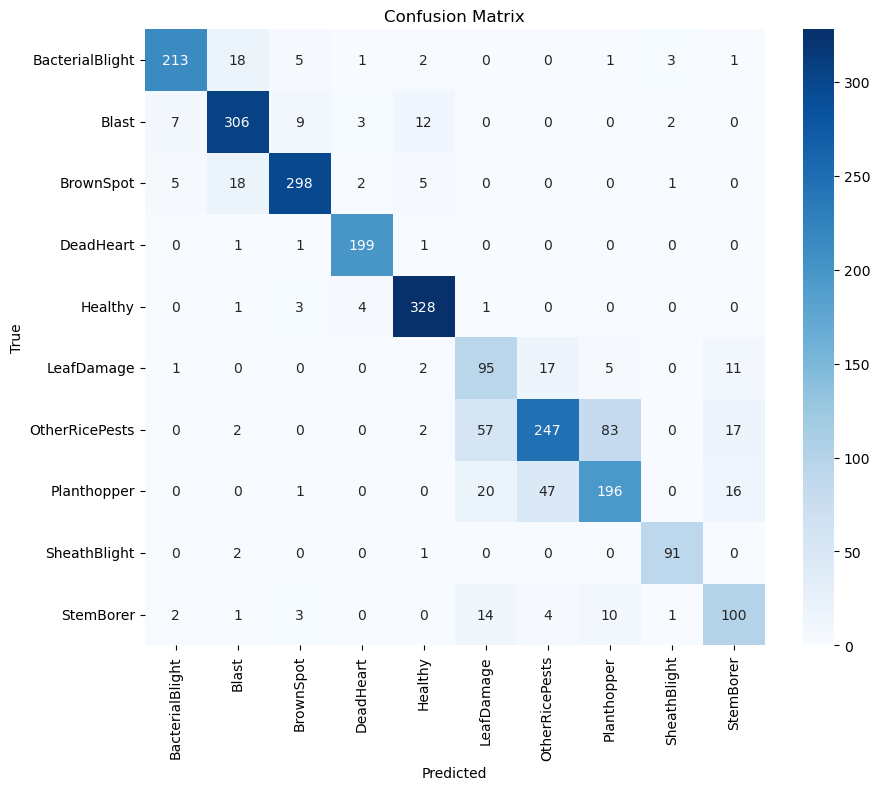

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()